In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<h3>Task 1: Load the dataset, print first 5 rows</h3>

In [14]:
df = pd.read_csv("project/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Print shape

In [15]:
print("Shape:", df.shape)

Shape: (768, 9)


<h3>Task 2: Check for missing values and basic statistics</h3>

In [18]:
print(df.isnull().sum())
print()
df.describe()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<h3>Task 3: Histogram of the 'Glucose' column</h3>

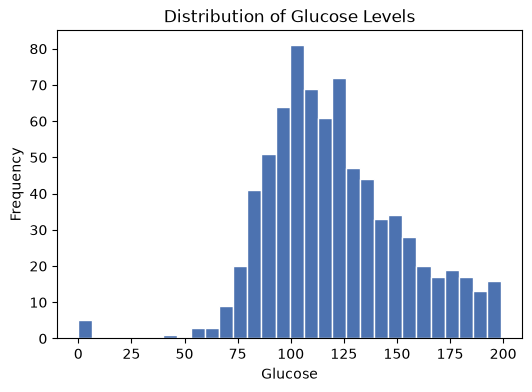

In [19]:
plt.figure(figsize=(6, 4))
plt.hist(df["Glucose"], bins=30, color="#4C72B0", edgecolor="white")
plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

<h4>Task 4: Split the data into features `X` and target `y`</h4>

In [20]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]
print(X.shape, y.shape)

(768, 8) (768,)


<h4>Task 5: 80-20 train-test split</h4>

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (614, 8)  Test: (154, 8)


<h4>Task 6-7: Train Logistic Regression and print accuracy</h4>

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred_log = logreg.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", acc_log)

Logistic Regression Accuracy: 0.7467532467532467


<h4>Task 8: Confusion matrix and classification report</h4>

In [23]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_log))

Confusion Matrix:
[[78 21]
 [18 37]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



<h4>Task 9: Train a Decision Tree and compare accuracy with Logistic Regression</h4>

In [24]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

y_pred_tree = dtree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", acc_tree)
print("Logistic Regression Accuracy:", acc_log)

Decision Tree Accuracy: 0.7467532467532467
Logistic Regression Accuracy: 0.7467532467532467


<h4>Task 10: Feature importances from the Decision Tree</h4>

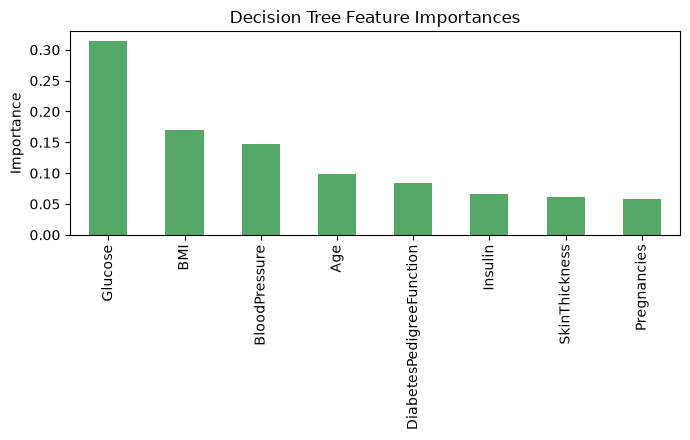

Glucose                     0.314225
BMI                         0.170700
BloodPressure               0.147679
Age                         0.099215
DiabetesPedigreeFunction    0.083282
Insulin                     0.066253
SkinThickness               0.061164
Pregnancies                 0.057482
dtype: float64


In [33]:
importances = pd.Series(dtree.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4.5))
importances.plot(kind="bar", color="#55A868")
plt.title("Decision Tree Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print(importances)